# Advanto Social Network Analysis
**Course: Social Networks in Organizations — Group Project**

Three datasets:
1. **Demographics** – individual attributes of the 26 managers
2. **Event attendance** – bipartite manager × event participation matrix
3. **Communication network** – directed work-communication ties

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
import seaborn as sns 
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
demo   = pd.read_csv('manager_demographics.csv')
events = pd.read_csv('event_attendance.csv').set_index('Manager')
edges  = pd.read_csv('communication_network.csv')

# pandas reads 'None' strings as NaN — restore as a label
demo['Legacy_Organization'] = demo['Legacy_Organization'].fillna('Post-merger')
demo['Favor_Merger']        = demo['Favor_Merger'].fillna('N/A')

print('Demographics:', demo.shape)
print('Events:', events.shape)
print('Edges:', edges.shape)
demo.head()

Demographics: (26, 8)
Events: (26, 8)
Edges: (102, 2)


,Manager,Gender,Age,Education,Legacy_Organization,Self_Monitoring,Brokerage_Orientation,Favor_Merger
0,1,F,30,MBA,Post-merger,5,TI,N/A
1,2,F,25,MSc,Brightway,2,TG,Y
2,3,M,40,MSc,Genesisphere,1,TG,Y
3,4,F,42,MBA,Post-merger,3,TI,N/A
4,5,F,54,MSc,Brightway,4,TG,Y


## 2. Demographics Analysis

Before analysing the network, we profile the 26 managers along key demographic and psychological dimensions. These attributes will serve as **predictors in the MR-QAP regression** (Section 5) to test which characteristics drive communication tie formation — and which ones do not.

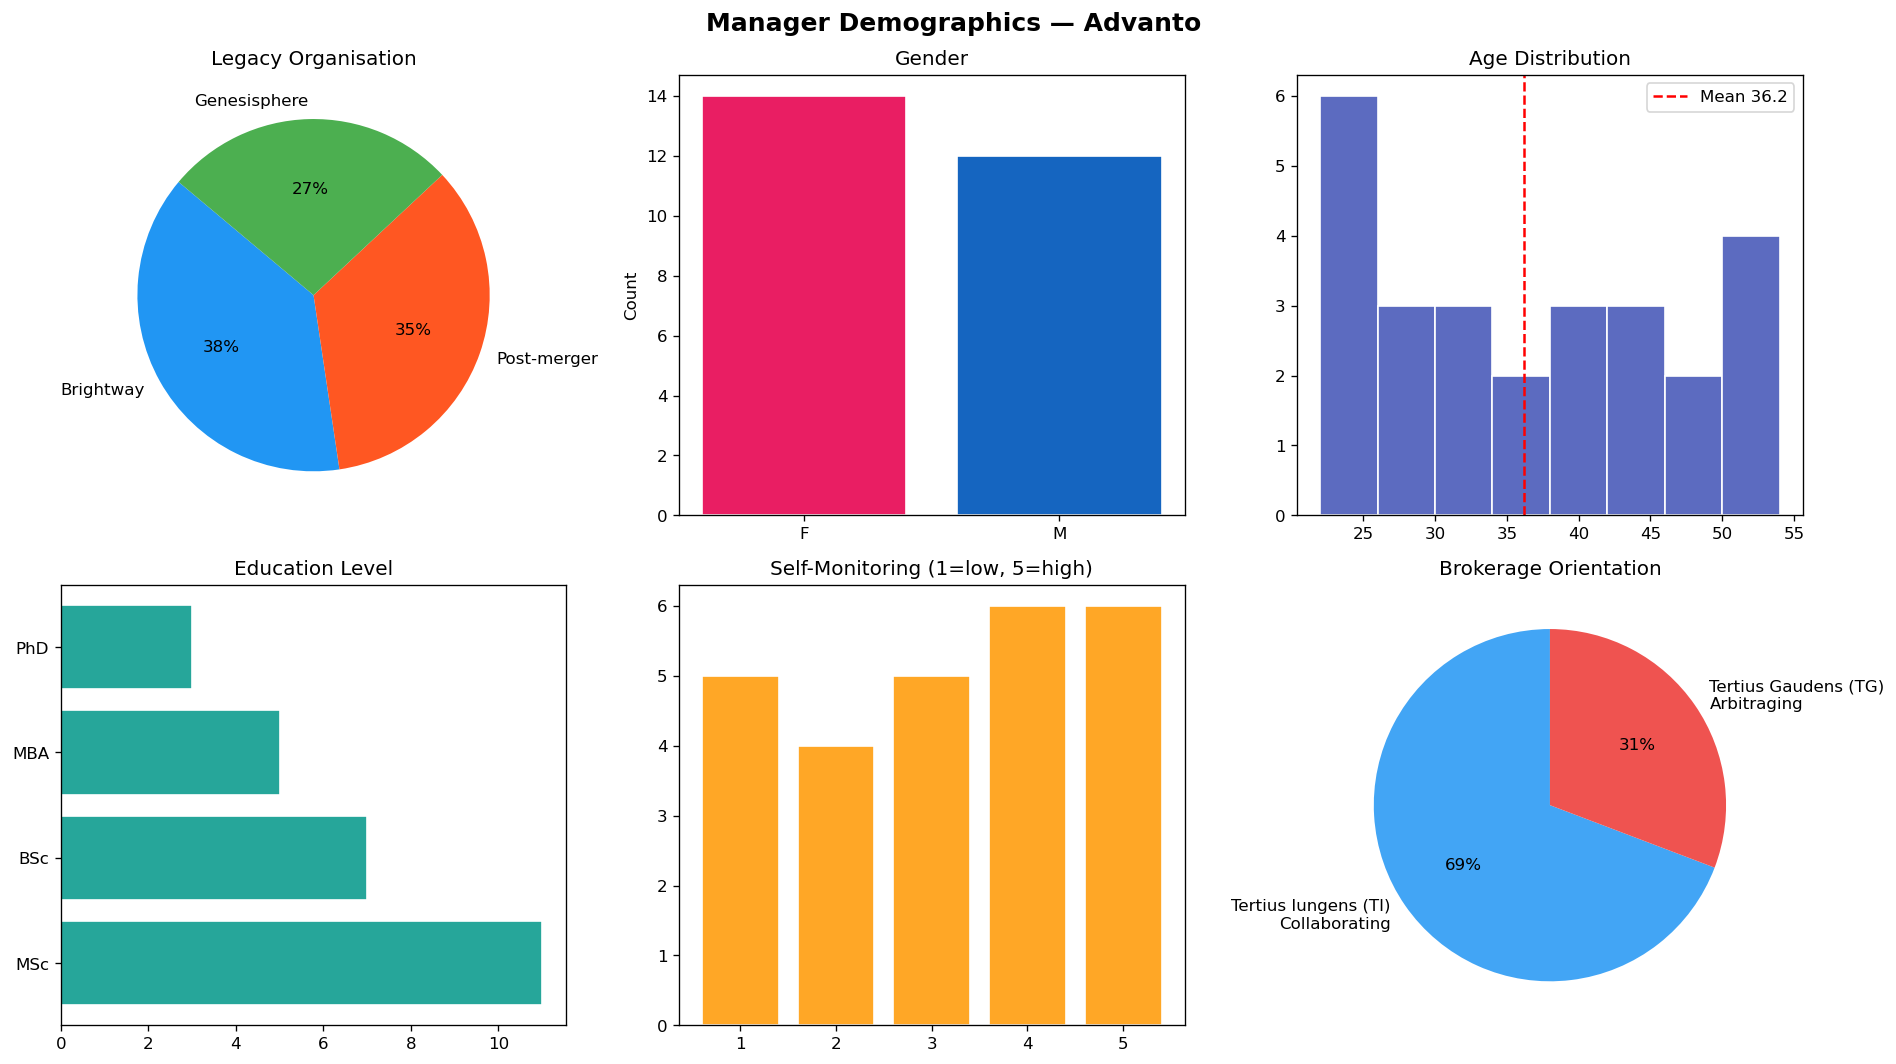

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Manager Demographics — Advanto', fontsize=15, fontweight='bold')

# Legacy organisation
lc = demo['Legacy_Organization'].value_counts()
axes[0,0].pie(lc, labels=lc.index, autopct='%1.0f%%',
              colors=['#2196F3','#FF5722','#4CAF50','#9E9E9E'], startangle=140)
axes[0,0].set_title('Legacy Organisation')

# Gender
gc = demo['Gender'].value_counts()
axes[0,1].bar(gc.index, gc.values, color=['#E91E63','#1565C0'], edgecolor='white')
axes[0,1].set_title('Gender')
axes[0,1].set_ylabel('Count')

# Age
axes[0,2].hist(demo['Age'], bins=8, color='#5C6BC0', edgecolor='white')
axes[0,2].axvline(demo['Age'].mean(), color='red', linestyle='--',
                  label=f'Mean {demo["Age"].mean():.1f}')
axes[0,2].set_title('Age Distribution')
axes[0,2].legend()

# Education
ec = demo['Education'].value_counts()
axes[1,0].barh(ec.index, ec.values, color='#26A69A', edgecolor='white')
axes[1,0].set_title('Education Level')

# Self-monitoring
sm = demo['Self_Monitoring'].value_counts().sort_index()
axes[1,1].bar(sm.index.astype(str), sm.values, color='#FFA726', edgecolor='white')
axes[1,1].set_title('Self-Monitoring (1=low, 5=high)')

# Brokerage orientation
bo = demo['Brokerage_Orientation'].value_counts()
axes[1,2].pie(bo, labels=['Tertius Iungens (TI)\nCollaborating',
                           'Tertius Gaudens (TG)\nArbitraging'],
              autopct='%1.0f%%', colors=['#42A5F5','#EF5350'], startangle=90)
axes[1,2].set_title('Brokerage Orientation')

plt.tight_layout()
plt.savefig('demographics_overview.png', bbox_inches='tight')
plt.show()

**Key demographic patterns:**
- **Three legacy groups:** Brightway (10, 38%), Genesisphere (7, 27%), post-merger hires (9, 35%)
- **Gender:** Near-equal split (~50/50 F/M)
- **Age:** Wide range 22–54 (mean ≈ 35) — potential generational divide in communication styles
- **Self-monitoring:** Bimodal distribution — many managers at extremes (1 or 5), few in the middle
- **Brokerage:** 69% TI (collaborative/connecting) vs 31% TG (arbitraging/exploiting gaps)

Merger support by legacy org:
Favor_Merger         N  Y
Legacy_Organization      
Brightway            3  7
Genesisphere         5  2

Percentages:
Favor_Merger            N     Y
Legacy_Organization            
Brightway            30.0  70.0
Genesisphere         71.4  28.6


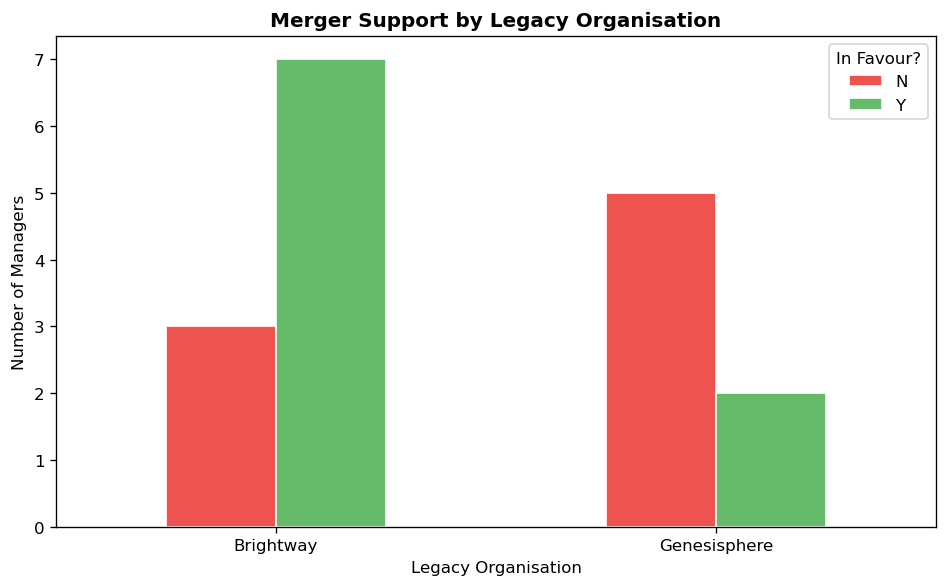

In [4]:
# Merger support by legacy org
favor = demo[(demo['Legacy_Organization'] != 'None') & (demo['Favor_Merger'] != 'N/A')].copy()
cross = pd.crosstab(favor['Legacy_Organization'], favor['Favor_Merger'])
print('Merger support by legacy org:')
print(cross)
print()
print('Percentages:')
print((cross.div(cross.sum(axis=1), axis=0) * 100).round(1))

fig, ax = plt.subplots(figsize=(8, 5))
cross.plot(kind='bar', ax=ax, color=['#EF5350','#66BB6A'], edgecolor='white', rot=0)
ax.set_title('Merger Support by Legacy Organisation', fontweight='bold')
ax.set_xlabel('Legacy Organisation')
ax.set_ylabel('Number of Managers')
ax.legend(title='In Favour?')
plt.tight_layout()
plt.savefig('merger_support.png', bbox_inches='tight')
plt.show()

**Critical finding — ideological split along legacy lines:**
- **Brightway:** 67% pro-merger (Y), 33% anti-merger (N)
- **Genesisphere:** 33% pro-merger, 67% anti-merger

The merger was designed as a 50:50 union, but attitudes are deeply asymmetric. Genesisphere managers predominantly oppose the integration — likely perceiving cultural or strategic loss. This divide maps directly onto the organizational boundaries the merger was supposed to dissolve, and is the primary motivation for the CEO's sabotage concern.

## 3. Event Attendance — Bipartite Network

Beyond daily communication, Advanto organizes company-wide events as a formal integration mechanism. We model attendance as a **bipartite network** (managers ↔ events) and project it onto a manager co-attendance network.

This reveals two things:
1. Whether events are actually mixing legacy groups (cross-legacy co-attendance rate)
2. Whether event co-attendance predicts work communication ties (tested in MR-QAP, Section 5)

In [5]:
events_total = events.sum(axis=1).rename('events_attended')
demo = demo.merge(events_total.reset_index(), on='Manager')

print('Events attended per manager:')
print(events_total.describe().round(2))
print(f'\nManagers attending 0 events: {(events_total == 0).sum()}')
print('\nAttendance per event:')
print(events.sum(axis=0))

Events attended per manager:
count    26.00
mean      1.31
std       0.97
min       0.00
25%       1.00
50%       1.00
75%       2.00
max       3.00
Name: events_attended, dtype: float64

Managers attending 0 events: 6

Attendance per event:
E1    5
E2    5
E3    4
E4    3
E5    3
E6    5
E7    6
E8    3
dtype: int64


**Attendance is sparse:** average 1.3 events per manager; **6 managers (23%) attended zero events** — they are completely absent from formal integration mechanisms. Low baseline participation limits events' integration potential before we even examine who attends with whom.

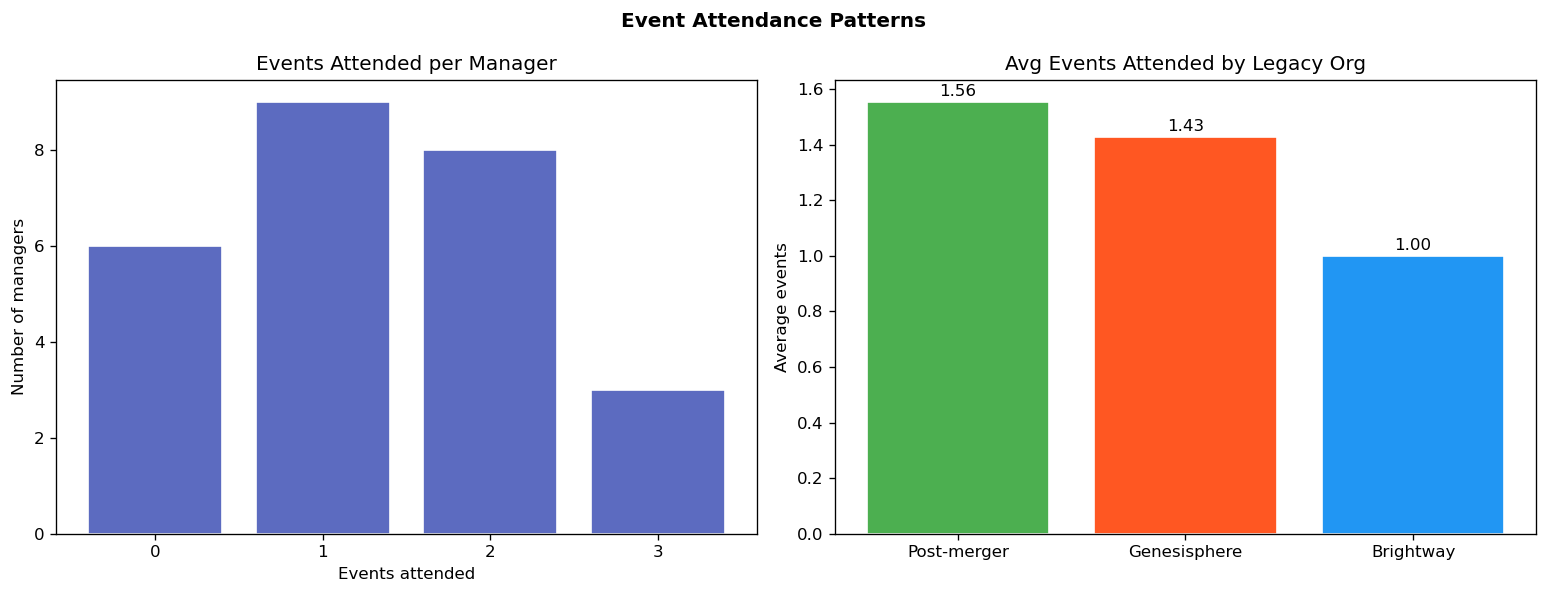

In [6]:
legacy_lookup = dict(zip(demo['Manager'], demo['Legacy_Organization']))
color_map_leg = {'Brightway':'#2196F3','Genesisphere':'#FF5722','Post-merger':'#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Event Attendance Patterns', fontweight='bold')

vc = events_total.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='#5C6BC0', edgecolor='white')
axes[0].set_title('Events Attended per Manager')
axes[0].set_xlabel('Events attended')
axes[0].set_ylabel('Number of managers')
axes[0].set_xticks(vc.index)

la = demo.groupby('Legacy_Organization')['events_attended'].mean().sort_values(ascending=False)
bars = axes[1].bar(la.index, la.values,
                   color=[color_map_leg.get(x,'grey') for x in la.index], edgecolor='white')
axes[1].set_title('Avg Events Attended by Legacy Org')
axes[1].set_ylabel('Average events')
for bar, val in zip(bars, la.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.savefig('event_attendance.png', bbox_inches='tight')
plt.show()

In [7]:
# Build bipartite graph
from networkx.algorithms import bipartite

B = nx.Graph()
managers_list = [f'M{i}' for i in range(1, 27)]
event_nodes   = events.columns.tolist()
B.add_nodes_from(managers_list, bipartite=0)
B.add_nodes_from(event_nodes, bipartite=1)

for mgr_id, row in events.iterrows():
    for evt, val in row.items():
        if val == 1:
            B.add_edge(f'M{mgr_id}', evt)

# Co-attendance projection
co_attend = bipartite.weighted_projected_graph(B, set(managers_list))

cross_leg = sum(1 for u, v in co_attend.edges()
                if legacy_lookup.get(int(u[1:]),'?') != legacy_lookup.get(int(v[1:]),'?')
                and legacy_lookup.get(int(u[1:]),'?') != 'None'
                and legacy_lookup.get(int(v[1:]),'?') != 'None')
print(f'Co-attendance network: {co_attend.number_of_nodes()} nodes, {co_attend.number_of_edges()} edges')
print(f'Cross-legacy co-attendance ties: {cross_leg}')

Co-attendance network: 26 nodes, 55 edges
Cross-legacy co-attendance ties: 33


In [8]:
def node_color(mid):
    return color_map_leg.get(legacy_lookup.get(mid, 'None'), 'grey')

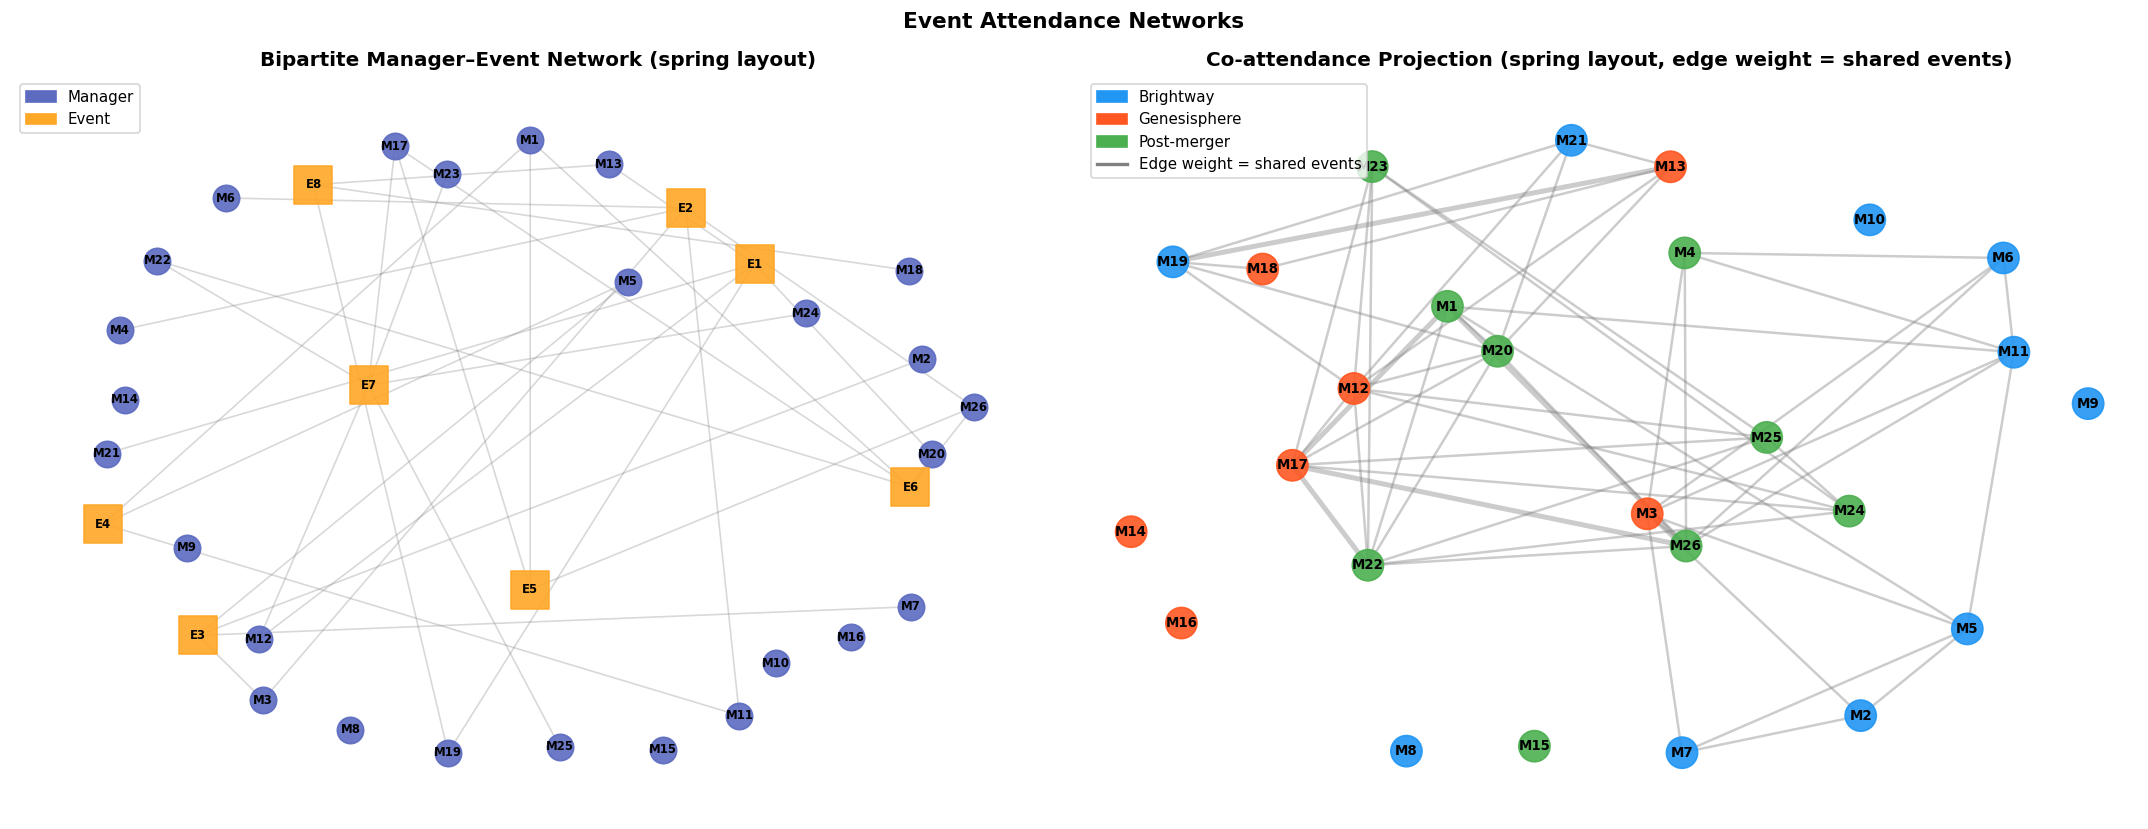

In [9]:

# --- Bipartite network: spring layout ---
manager_nodes = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 0]
event_nodes_b = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 1]

pos_B = nx.spring_layout(B, seed=42, k=2.0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Event Attendance Networks', fontsize=13, fontweight='bold')

# Bipartite graph
nx.draw_networkx_edges(B, pos_B, alpha=0.3, edge_color='grey', ax=axes[0])
nx.draw_networkx_nodes(B, pos_B, nodelist=manager_nodes, node_color='#5C6BC0',
                       node_size=250, node_shape='o', alpha=0.9, ax=axes[0])
nx.draw_networkx_nodes(B, pos_B, nodelist=event_nodes_b, node_color='#FFA726',
                       node_size=500, node_shape='s', alpha=0.9, ax=axes[0])
nx.draw_networkx_labels(B, pos_B, font_size=7, font_weight='bold', ax=axes[0])
axes[0].legend(handles=[
    mpatches.Patch(color='#5C6BC0', label='Manager'),
    mpatches.Patch(color='#FFA726', label='Event'),
], loc='upper left', fontsize=9)
axes[0].set_title('Bipartite Manager–Event Network (spring layout)', fontweight='bold')
axes[0].axis('off')

# Co-attendance projection
pos_co = nx.spring_layout(co_attend, seed=42, k=2.0)
edge_weights = [co_attend[u][v]['weight'] for u, v in co_attend.edges()]
node_colors_co = [node_color(int(n[1:])) for n in co_attend.nodes()]
nx.draw_networkx_edges(co_attend, pos_co, width=[w * 1.5 for w in edge_weights],
                       alpha=0.4, edge_color='grey', ax=axes[1])
nx.draw_networkx_nodes(co_attend, pos_co, node_color=node_colors_co, node_size=350,
                       alpha=0.9, ax=axes[1])
nx.draw_networkx_labels(co_attend, pos_co, font_size=8, font_weight='bold', ax=axes[1])
axes[1].legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
    Line2D([0],[0], color='grey', linewidth=2, label='Edge weight = shared events'),
], loc='upper left', fontsize=9)
axes[1].set_title('Co-attendance Projection (spring layout, edge weight = shared events)',
                  fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('bipartite_coattendance.png', bbox_inches='tight')
plt.show()


### Key Insight: Co-attendance as Integration Lever

Cross-legacy co-attendance accounts for **33 of 55 ties (60%)** in the event network — higher cross-legacy mixing than the communication network (47%). Events already bridge legacy groups more than spontaneous communication does.

**Confirmed in MR-QAP (Section 5):** Co-attendance is the strongest and most significant predictor of communication ties (β ≈ +0.12, p < .01) — stronger than any demographic attribute. Deliberately designing future events to mix Brightway and Genesisphere managers is the single most actionable integration lever.

## 4. Communication Network — Core Analysis

The communication network is the central object of our analysis. We construct a **directed graph** from self-reported work communication ties among all 26 managers and compute five centrality measures to profile each manager's structural position.

These positions determine two things:
1. **Integration potential** — who can bridge legacy groups (→ Task Force, Section 7)
2. **Sabotage risk** — who can block integration from a position of structural power (→ Section 6)

In [10]:
# Build directed and undirected communication graphs
G_dir = nx.DiGraph()
G_dir.add_nodes_from(demo['Manager'])
for _, row in edges.iterrows():
    G_dir.add_edge(int(row['Source']), int(row['Target']))

G = G_dir.to_undirected()

print(f'Directed:   {G_dir.number_of_nodes()} nodes, {G_dir.number_of_edges()} edges')
print(f'Undirected: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Directed:   26 nodes, 102 edges
Undirected: 26 nodes, 51 edges


In [11]:
# Centrality measures
deg_in    = dict(G_dir.in_degree())
deg_out   = dict(G_dir.out_degree())
deg_total = dict(G.degree())
between   = nx.betweenness_centrality(G, normalized=True)
closeness = nx.closeness_centrality(G)
eigenvec  = nx.eigenvector_centrality(G, max_iter=500)
constraint_vals = nx.constraint(G)

centrality_df = pd.DataFrame({
    'Manager':    list(G.nodes()),
    'Degree':     [deg_total[n] for n in G.nodes()],
    'In_Degree':  [deg_in.get(n, 0) for n in G.nodes()],
    'Out_Degree': [deg_out.get(n, 0) for n in G.nodes()],
    'Betweenness':[between[n]   for n in G.nodes()],
    'Closeness':  [closeness[n] for n in G.nodes()],
    'Eigenvector':[eigenvec[n]  for n in G.nodes()],
    'Constraint': [constraint_vals[n] for n in G.nodes()],
})
centrality_df = (centrality_df
                 .sort_values('Manager')
                 .merge(demo[['Manager','Legacy_Organization','Brokerage_Orientation',
                               'Self_Monitoring','Favor_Merger','events_attended']], on='Manager')
                 .reset_index(drop=True))

print('Top 10 by Betweenness:')
print(centrality_df.sort_values('Betweenness', ascending=False)[
    ['Manager','Legacy_Organization','Degree','Betweenness','Closeness','Constraint']
].head(10).round(4).to_string(index=False))

Top 10 by Betweenness:
 Manager Legacy_Organization  Degree  Betweenness  Closeness  Constraint
      11           Brightway       4       0.5000     0.3846      0.3753
       1         Post-merger       5       0.3556     0.3571      0.2888
       8           Brightway       5       0.3514     0.3906      0.3339
      22         Post-merger       3       0.2811     0.2907      0.3333
      13        Genesisphere       4       0.2339     0.3425      0.4319
      12        Genesisphere       4       0.1972     0.3378      0.4319
       6           Brightway       5       0.1664     0.3623      0.3609
      17        Genesisphere       7       0.1586     0.2941      0.3017
      14        Genesisphere       5       0.1214     0.2874      0.2848
      26         Post-merger       3       0.0733     0.2358      0.5062


**Centrality measures:**
- **Betweenness:** fraction of shortest paths passing through a node — measures information control and bridge potential
- **Closeness:** inverse average distance to all others — measures how quickly a manager can reach the whole network
- **Eigenvector:** connection to well-connected others — quality of connections, not just quantity
- **Burt's Constraint:** how redundant a manager's contacts are — *low constraint* = structural hole broker spanning disconnected groups; *high constraint* = embedded in a single dense cluster

In [12]:
top10 = (centrality_df
    .sort_values('Betweenness', ascending=False)
    .head(10)[['Manager','Legacy_Organization','Favor_Merger',
               'Brokerage_Orientation','Degree','Betweenness','Constraint']]
    .rename(columns={
        'Legacy_Organization':   'Legacy Org',
        'Favor_Merger':          'Pro Merger?',
        'Brokerage_Orientation': 'Brokerage',
    })
    .assign(Manager=lambda df: df['Manager'].apply(lambda x: f'M{int(x)}'))
    .reset_index(drop=True)
)

top10.style \
    .set_caption('Top 10 Managers by Betweenness Centrality') \
    .format({'Betweenness': '{:.3f}', 'Constraint': '{:.3f}'}) \
    .background_gradient(subset=['Betweenness'], cmap='YlOrRd') \
    .background_gradient(subset=['Constraint'], cmap='YlGn_r') \
    .set_properties(**{'text-align': 'center'}) \
    .hide(axis='index')


Manager,Legacy Org,Pro Merger?,Brokerage,Degree,Betweenness,Constraint
M11,Brightway,N,TG,4,0.500,0.375
M1,Post-merger,N/A,TI,5,0.356,0.289
M8,Brightway,N,TG,5,0.351,0.334
M22,Post-merger,N/A,TG,3,0.281,0.333
M13,Genesisphere,N,TI,4,0.234,0.432
M12,Genesisphere,N,TI,4,0.197,0.432
M6,Brightway,Y,TI,5,0.166,0.361
M17,Genesisphere,Y,TI,7,0.159,0.302
M14,Genesisphere,N,TI,5,0.121,0.285
M26,Post-merger,N/A,TI,3,0.073,0.506


**Key structural players:**
- **M11** (Brightway): Highest betweenness (0.50) — more than any other manager. Sits at the critical bridge between Brightway and Genesisphere clusters.
- **M1** (Post-merger): Second highest betweenness (0.36), lowest constraint (0.29) — strongest cross-legacy broker in the network.
- **M8, M22** (Brightway, Post-merger): High betweenness with significant broker potential.

Three managers — M1, M11, M22 — are **articulation points**: removing any one of them disconnects the communication network entirely.

### 4.1 Network Visualisation

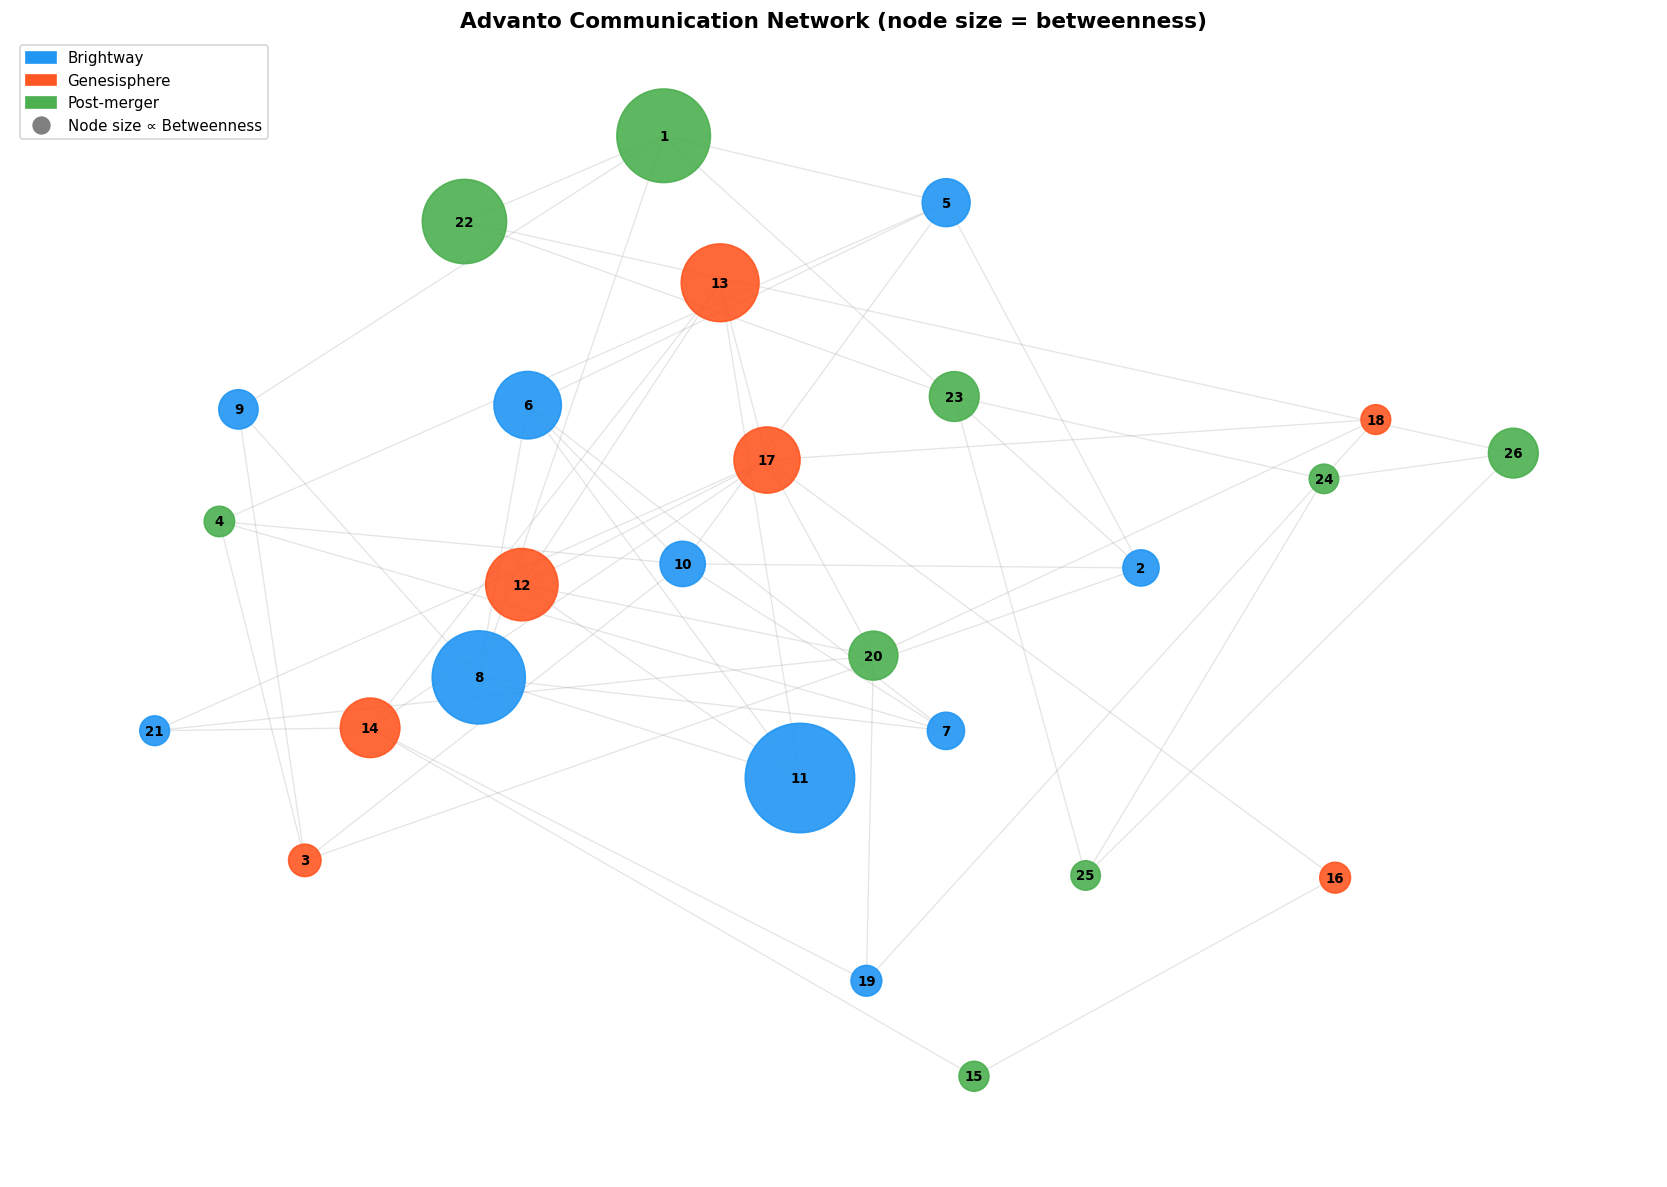

In [13]:
def node_color(mid):
    return color_map_leg.get(legacy_lookup.get(mid, 'None'), 'grey')

node_color_list = [node_color(n) for n in G.nodes()]
node_size_list  = [300 + between[n] * 8000 for n in G.nodes()]
pos = nx.spring_layout(G, seed=42, k=1.5)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='#999', ax=ax, width=0.8)
nx.draw_networkx_nodes(G, pos, node_color=node_color_list,
                       node_size=node_size_list, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
legend_els = [
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
           markersize=12, label='Node size ∝ Betweenness'),
]
ax.legend(handles=legend_els, loc='upper left', fontsize=9)
ax.set_title('Advanto Communication Network (node size = betweenness)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('communication_network.png', bbox_inches='tight')
plt.show()

**Visual pattern:** Three clusters are visible — a Brightway-dominated cluster (bottom), a Genesisphere-dominated cluster (top-right), and a post-merger isolate cluster (right). Cross-legacy ties exist but pass through a small number of bridge managers. Node size reflects betweenness — the largest nodes (M11, M1, M8) are the structural linchpins of the entire network.

### 4.2 Legacy Clustering — E-I Index

In [14]:
# Count within vs cross-legacy ties
within_bw, within_gs, cross_ties, other = 0, 0, 0, 0
for u, v in G.edges():
    ou, ov = legacy_lookup.get(u,'None'), legacy_lookup.get(v,'None')
    if   ou == 'Brightway'    and ov == 'Brightway':    within_bw += 1
    elif ou == 'Genesisphere' and ov == 'Genesisphere': within_gs += 1
    elif ou != 'None' and ov != 'None' and ou != ov:    cross_ties += 1
    else: other += 1

total = G.number_of_edges()
print(f'Total undirected edges: {total}')
print(f'Within-Brightway:     {within_bw} ({100*within_bw/total:.1f}%)')
print(f'Within-Genesisphere:  {within_gs} ({100*within_gs/total:.1f}%)')
print(f'Cross-legacy:         {cross_ties} ({100*cross_ties/total:.1f}%)')
print(f'Involving post-merger:{other} ({100*other/total:.1f}%)')

# E-I index per legacy group
for grp in ['Brightway','Genesisphere']:
    members = {n for n, g in legacy_lookup.items() if g == grp}
    internal = sum(1 for u,v in G.edges() if u in members and v in members)
    external = sum(1 for u,v in G.edges()
                   if (u in members) != (v in members)
                   and legacy_lookup.get(u,'None') != 'None'
                   and legacy_lookup.get(v,'None') != 'None')
    ei = (external - internal) / (external + internal) if (external+internal) > 0 else None
    print(f'{grp}: internal={internal}, external={external}, EI={ei:.3f}')

Total undirected edges: 51
Within-Brightway:     12 (23.5%)
Within-Genesisphere:  7 (13.7%)
Cross-legacy:         24 (47.1%)
Involving post-merger:8 (15.7%)
Brightway: internal=12, external=18, EI=0.200
Genesisphere: internal=7, external=15, EI=0.364


**E-I Index interpretation** (range −1 = fully insular → +1 = fully outward):
- **Brightway EI = +0.20**: Slightly more external than internal ties — cross-legacy ties exist but are concentrated among a few brokers
- **Genesisphere EI = +0.36**: Higher external orientation, but driven by connections to Brightway, not post-merger hires

Both values are positive, which appears encouraging. However, cross-legacy ties are not evenly distributed — they are mediated by a small number of bridge managers. Remove M11, M1, or M22 (articulation points) and both legacy groups become structurally disconnected. The E-I index masks this fragility.

### 4.3 Community Detection

In [15]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))
modularity  = nx.community.modularity(G, communities)

print(f'Communities detected: {len(communities)}')
for i, comm in enumerate(communities):
    tags = [f'{n}({legacy_lookup.get(n,"?")[:2]})' for n in sorted(comm)]
    print(f'  C{i+1}: {tags}')
print(f'\nModularity Q = {modularity:.4f}')

Communities detected: 3
  C1: ['11(Br)', '12(Ge)', '13(Ge)', '14(Ge)', '15(Po)', '16(Ge)', '17(Ge)', '18(Ge)', '19(Br)', '20(Po)', '21(Br)']
  C2: ['1(Po)', '2(Br)', '3(Ge)', '4(Po)', '5(Br)', '6(Br)', '7(Br)', '8(Br)', '9(Br)', '10(Br)']
  C3: ['22(Po)', '23(Po)', '24(Po)', '25(Po)', '26(Po)']

Modularity Q = 0.5554


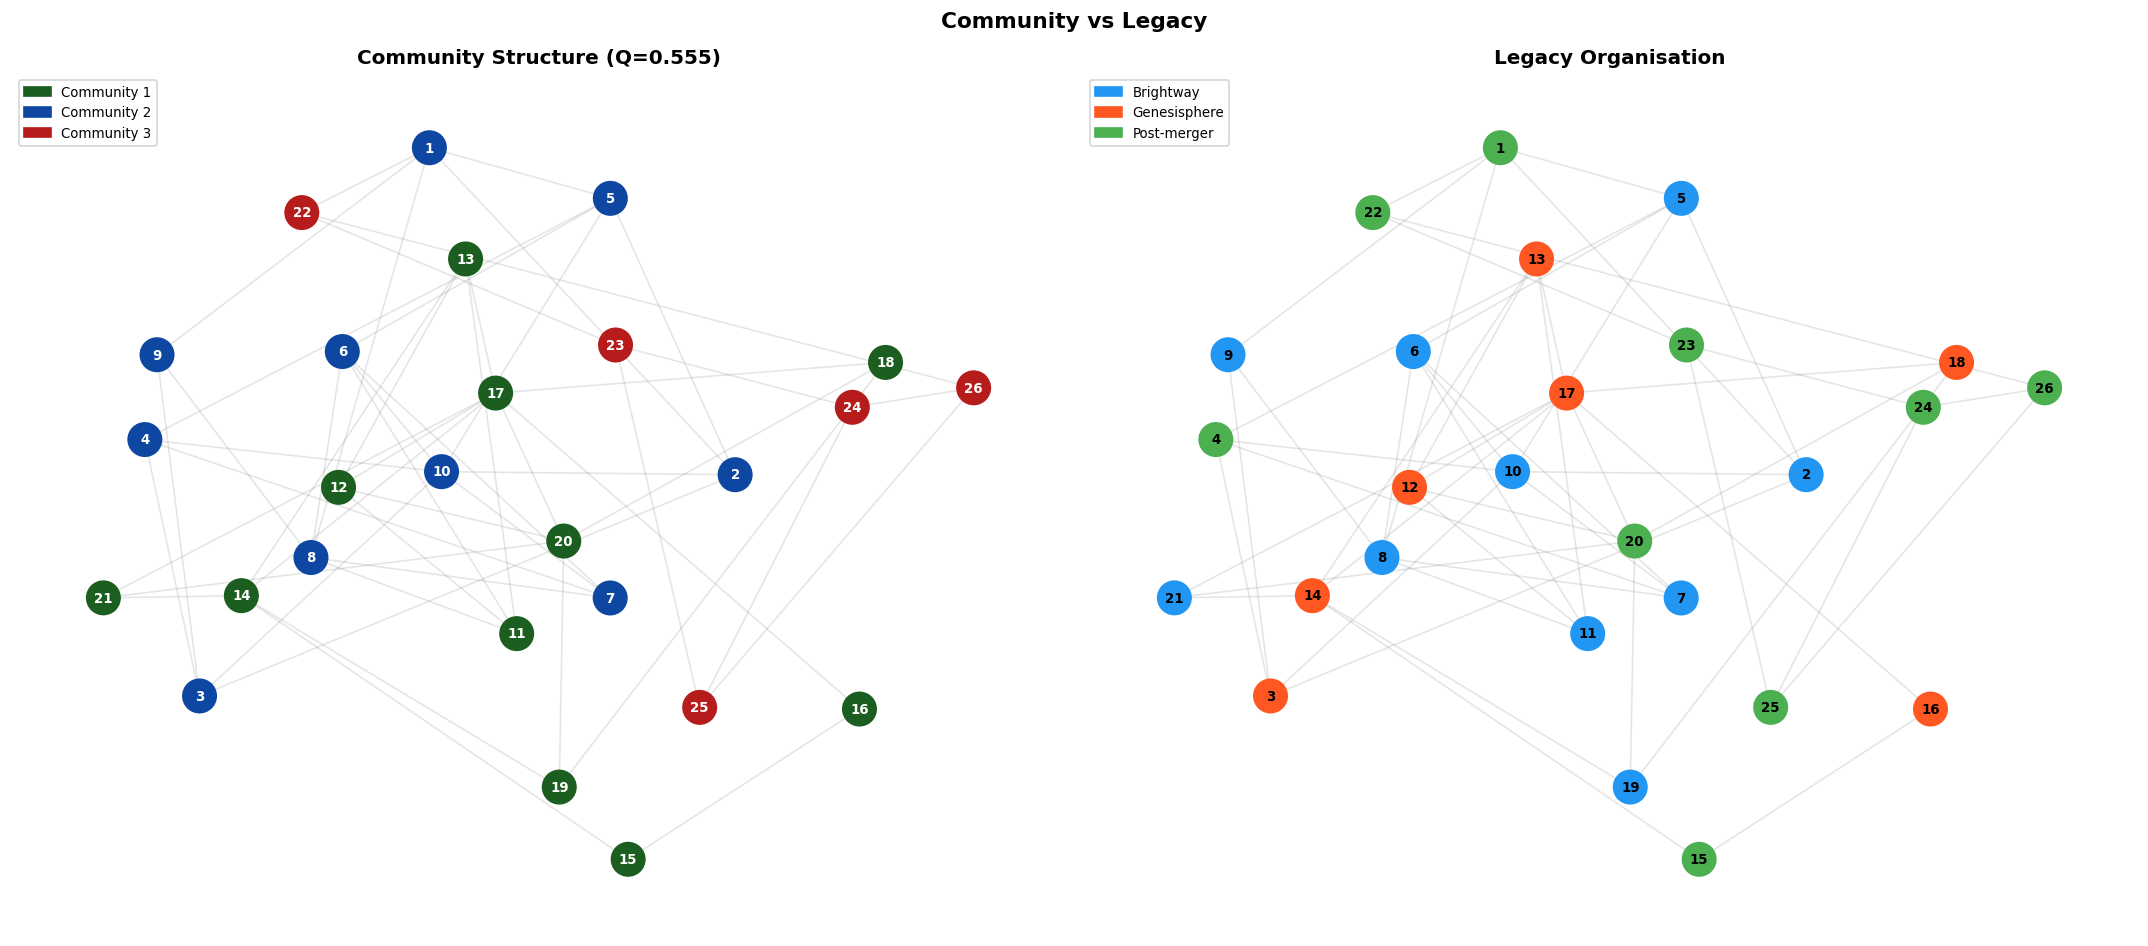

In [16]:
comm_map = {n: i for i, comm in enumerate(communities) for n in comm}
palette  = ['#1B5E20','#0D47A1','#B71C1C','#F57F17','#4A148C']
node_comm_colors = [palette[comm_map[n] % len(palette)] for n in G.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# By community
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='grey', ax=axes[0])
nx.draw_networkx_nodes(G, pos, node_color=node_comm_colors, node_size=400, ax=axes[0])
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=axes[0])
axes[0].legend(handles=[mpatches.Patch(color=palette[i], label=f'Community {i+1}')
               for i in range(len(communities))], loc='upper left', fontsize=8)
axes[0].set_title(f'Community Structure (Q={modularity:.3f})', fontweight='bold')
axes[0].axis('off')

# By legacy
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='grey', ax=axes[1])
nx.draw_networkx_nodes(G, pos, node_color=node_color_list, node_size=400, ax=axes[1])
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=axes[1])
axes[1].legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
], loc='upper left', fontsize=8)
axes[1].set_title('Legacy Organisation', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Community vs Legacy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('community_vs_legacy.png', bbox_inches='tight')
plt.show()

**Community ↔ Legacy overlap:** The three detected communities do not map cleanly onto legacy boundaries (Q = 0.556 — strong but not perfect modularity):
- **C1** (11 members): Genesisphere-heavy, centred on M11–M21 sub-cluster
- **C2** (10 members): Brightway-heavy core, includes M1 (post-merger) as central hub
- **C3** (5 members): Almost entirely post-merger hires — the most structurally isolated group

The partial misalignment between communities and legacy orgs shows informal relationships partially transcend legacy boundaries. However, C3's isolation means post-merger hires are neither integrated into Brightway nor Genesisphere communication patterns — a secondary integration failure beyond the Brightway–Genesisphere divide.

### 4.4 Articulation Points & Structural Holes

In [17]:
artic = sorted(nx.articulation_points(G))
print('Articulation points (removal disconnects network):', artic)

print('\nTop structural hole brokers (lowest Burt constraint):')
print(centrality_df.sort_values('Constraint')[
    ['Manager','Legacy_Organization','Brokerage_Orientation',
     'Betweenness','Constraint']
].head(10).round(4).to_string(index=False))

Articulation points (removal disconnects network): [1, 11, 22]

Top structural hole brokers (lowest Burt constraint):
 Manager Legacy_Organization Brokerage_Orientation  Betweenness  Constraint
      14        Genesisphere                    TI       0.1214      0.2848
       1         Post-merger                    TI       0.3556      0.2888
      17        Genesisphere                    TI       0.1586      0.3017
      22         Post-merger                    TG       0.2811      0.3333
       8           Brightway                    TG       0.3514      0.3339
       6           Brightway                    TI       0.1664      0.3609
       5           Brightway                    TG       0.0653      0.3617
       3        Genesisphere                    TG       0.0094      0.3733
      11           Brightway                    TG       0.5000      0.3753
      10           Brightway                    TG       0.0542      0.3983


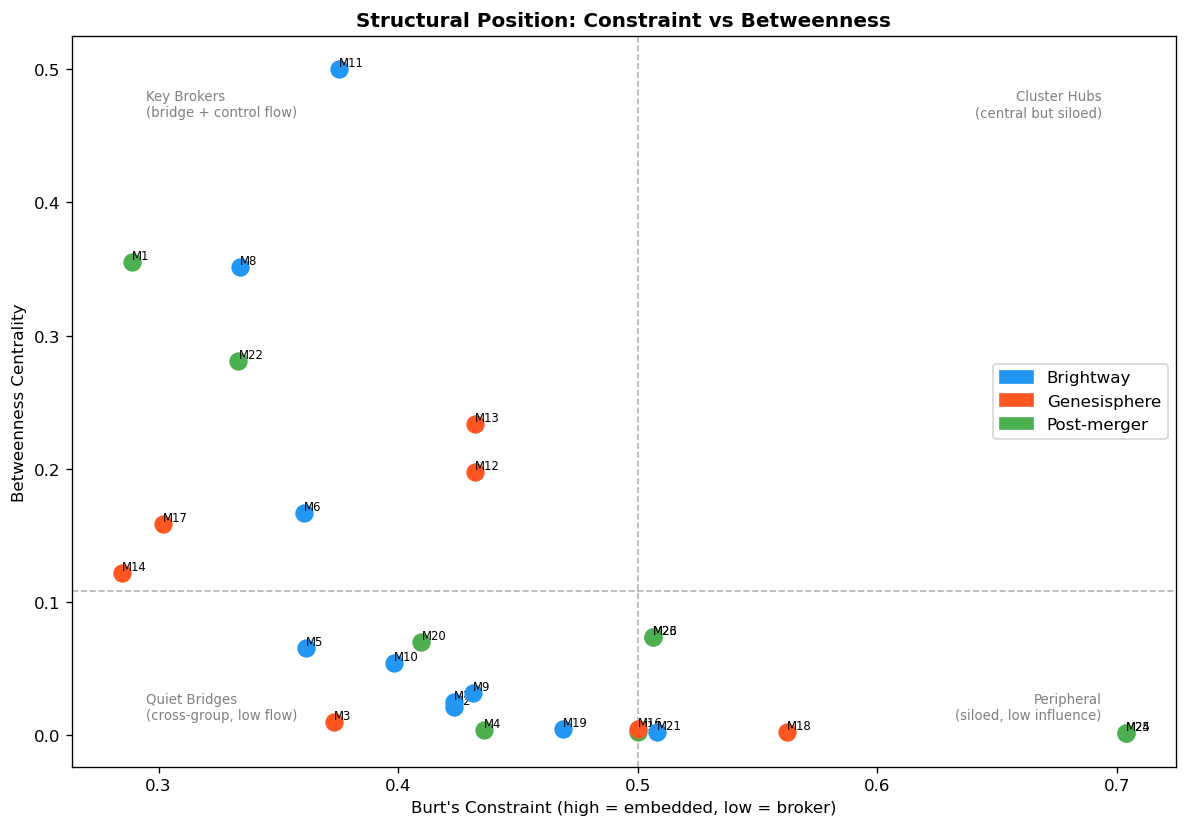

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

threshold_constraint  = 0.5
threshold_betweenness = centrality_df['Betweenness'].mean()

ax.axvline(threshold_constraint,  color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(threshold_betweenness, color='grey', linestyle='--', linewidth=1, alpha=0.6)

# Quadrant labels
ax.text(centrality_df['Constraint'].min() + 0.01, centrality_df['Betweenness'].max() * 0.97,
        'Key Brokers\n(bridge + control flow)', fontsize=8, color='grey', va='top')
ax.text(centrality_df['Constraint'].max() - 0.01, centrality_df['Betweenness'].max() * 0.97,
        'Cluster Hubs\n(central but siloed)', fontsize=8, color='grey', va='top', ha='right')
ax.text(centrality_df['Constraint'].min() + 0.01, threshold_betweenness * 0.3,
        'Quiet Bridges\n(cross-group, low flow)', fontsize=8, color='grey', va='top')
ax.text(centrality_df['Constraint'].max() - 0.01, threshold_betweenness * 0.3,
        'Peripheral\n(siloed, low influence)', fontsize=8, color='grey', va='top', ha='right')

for _, row in centrality_df.iterrows():
    c = color_map_leg.get(row['Legacy_Organization'], 'grey')
    ax.scatter(row['Constraint'], row['Betweenness'], color=c, s=100, zorder=3)
    ax.annotate(f"M{int(row['Manager'])}", (row['Constraint'], row['Betweenness']),
                fontsize=7, ha='left', va='bottom')

ax.set_xlabel("Burt's Constraint (high = embedded, low = broker)")
ax.set_ylabel('Betweenness Centrality')
ax.set_title('Structural Position: Constraint vs Betweenness', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger'),
])
plt.tight_layout()
plt.savefig('constraint_betweenness.png', bbox_inches='tight')
plt.show()


**Structural brokers (top-left quadrant: low constraint, high betweenness):** M1, M8, M11, and M22 occupy structural holes — they bridge otherwise disconnected groups and control information flow. 

**Critical distinction:** M11 has the *highest* betweenness but moderate constraint, indicating it acts as a gatekeeper rather than a true open broker. Managers with *both* low constraint and high betweenness (M1, M14, M17) are the most effective integration bridges — they span multiple groups without being exclusively tied to any one.

## 5. MR-QAP Regression: Do Demographics Predict Communication Ties?

**Motivation:** Standard OLS regression assumes observations are independent. Network data violates this — if M1 talks to M3 and M1 talks to M5, then M3–M5 are correlated. OLS p-values are biased.

**Solution — QAP (Quadratic Assignment Procedure):** Permute the rows *and* columns of the adjacency matrix Y simultaneously (= randomly relabel nodes), refit OLS each time, and build an empirical null distribution. P-value = proportion of permuted coefficients ≥ observed.

**MR-QAP** extends this to multiple predictors simultaneously, controlling for all attributes at once.

In [19]:
# --- Build 26×26 predictor matrices ---
import statsmodels.api as sm

n = 26
d = demo.sort_values('Manager').reset_index(drop=True)   # guarantee order 1..26

leg  = d['Legacy_Organization'].values
gen  = d['Gender'].values
age  = d['Age'].values.astype(float)
edu  = d['Education'].values
smv  = d['Self_Monitoring'].values.astype(float)
brok = d['Brokerage_Orientation'].values
fav  = d['Favor_Merger'].values

# Binary same-attribute matrices
same_legacy = (leg[:,None]  == leg[None,:]).astype(float)
same_gender = (gen[:,None]  == gen[None,:]).astype(float)
same_edu    = (edu[:,None]  == edu[None,:]).astype(float)
same_brok   = (brok[:,None] == brok[None,:]).astype(float)
same_merger = (fav[:,None]  == fav[None,:]).astype(float)   # N/A treated as its own category

# Continuous difference matrices (standardised so coefficients are per-SD)
age_raw  = np.abs(age[:,None] - age[None,:])
sm_raw   = np.abs(smv[:,None] - smv[None,:])

mask_off = ~np.eye(n, dtype=bool)
age_diff = age_raw / age_raw[mask_off].std()
sm_diff  = sm_raw  / sm_raw[mask_off].std()

# Co-attendance matrix (from existing NetworkX projection)
node_order    = [f'M{i}' for i in range(1, n+1)]
co_attend_mat = nx.to_numpy_array(co_attend, nodelist=node_order, weight='weight')

# Zero all diagonals
for M in [same_legacy, same_gender, same_edu, same_brok, same_merger,
          age_diff, sm_diff, co_attend_mat]:
    np.fill_diagonal(M, 0)

pred_names = ['same_legacy','same_gender','age_diff','same_edu',
              'sm_diff','same_brok','same_merger','co_attend']
pred_mats  = [same_legacy, same_gender, age_diff, same_edu,
              sm_diff, same_brok, same_merger, co_attend_mat]

print('Predictor matrices built. Shapes:', same_legacy.shape)
print('Dyads per matrix (off-diagonal):', mask_off.sum())

Predictor matrices built. Shapes: (26, 26)
Dyads per matrix (off-diagonal): 650


In [20]:
# --- Build 26×26 adjacency matrix Y and flatten everything to vectors ---
Y = np.zeros((n, n), dtype=float)
for _, row in edges.iterrows():
    Y[int(row['Source'])-1, int(row['Target'])-1] = 1.0

print(f'Adjacency matrix: {int(Y.sum())} directed edges')
print(f'Symmetric (fully reciprocal): {np.allclose(Y, Y.T)}')   # expected: True

# Flatten: 650 off-diagonal dyads
y_vec = Y[mask_off]
X_mat = np.column_stack([M[mask_off] for M in pred_mats])

print(f'y_vec shape: {y_vec.shape}, positive ties: {int(y_vec.sum())}')
print(f'X_mat shape: {X_mat.shape}')

Adjacency matrix: 102 directed edges
Symmetric (fully reciprocal): True
y_vec shape: (650,), positive ties: 102
X_mat shape: (650, 8)


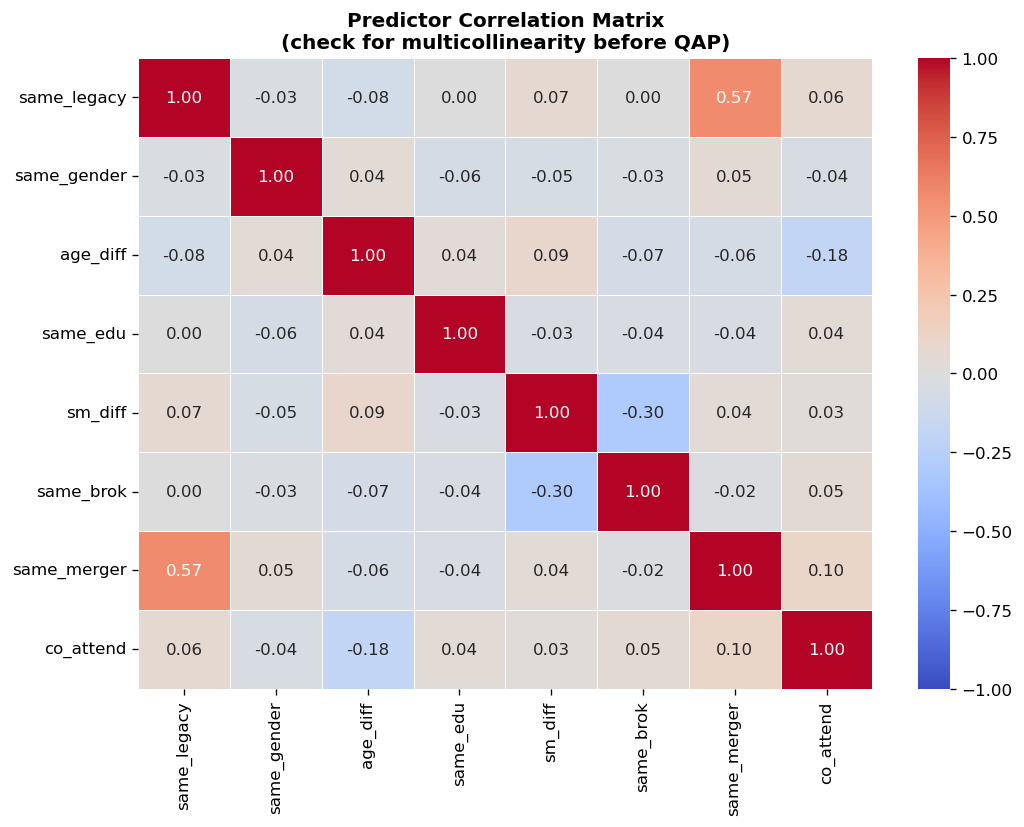

Highest correlation: same_legacy ↔ same_merger: r=0.569


In [21]:
# --- Predictor collinearity check ---
pred_df  = pd.DataFrame(X_mat, columns=pred_names)
corr_mat = pred_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Predictor Correlation Matrix\n(check for multicollinearity before QAP)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highest pair
corr_vals = corr_mat.abs().where(~np.eye(len(pred_names), dtype=bool))
max_pair  = corr_vals.stack().idxmax()
print(f'Highest correlation: {max_pair[0]} ↔ {max_pair[1]}: r={corr_mat.loc[max_pair]:.3f}')

In [22]:
# --- OLS baseline (reference only — p-values invalid for dyadic data) ---
X_const   = sm.add_constant(X_mat)
ols_model = sm.OLS(y_vec, X_const).fit()

print('=' * 60)
print('OLS BASELINE — ⚠ p-values INVALID for dyadic data')
print('Use QAP p-values from permutation test below')
print('=' * 60)
print(ols_model.summary(xname=['const'] + pred_names))

OLS BASELINE — ⚠ p-values INVALID for dyadic data
Use QAP p-values from permutation test below
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     7.854
Date:                Sun, 03 May 2026   Prob (F-statistic):           4.23e-10
Time:                        19:02:25   Log-Likelihood:                -234.54
No. Observations:                 650   AIC:                             487.1
Df Residuals:                     641   BIC:                             527.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [23]:
# --- MR-QAP permutation engine ---
def run_qap(Y, X_mat, pred_names, n_perms=9999, seed=42):
    np.random.seed(seed)
    n_nodes  = Y.shape[0]
    mask     = ~np.eye(n_nodes, dtype=bool)
    X_const  = sm.add_constant(X_mat)
    k        = len(pred_names)

    obs_model = sm.OLS(Y[mask], X_const).fit()
    obs_coefs = obs_model.params[1:]     # exclude intercept
    obs_r2    = obs_model.rsquared

    null_coefs = np.zeros((n_perms, k))
    null_r2    = np.zeros(n_perms)

    for p in range(n_perms):
        perm          = np.random.permutation(n_nodes)
        Y_perm        = Y[np.ix_(perm, perm)]           # permute rows+cols simultaneously
        m             = sm.OLS(Y_perm[mask], X_const).fit()
        null_coefs[p] = m.params[1:]
        null_r2[p]    = m.rsquared

    return obs_coefs, obs_r2, null_coefs, null_r2

print('Running QAP (9999 permutations)...')
obs_coefs, obs_r2, null_coefs, null_r2 = run_qap(Y, X_mat, pred_names)
print('Done.')

Running QAP (9999 permutations)...


Done.


In [24]:
# --- QAP results table ---
n_perms = 9999

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return 'ns'

pvals = np.array([
    (np.sum(np.abs(null_coefs[:, i]) >= np.abs(obs_coefs[i])) + 1) / (n_perms + 1)
    for i in range(len(pred_names))
])
r2_pval = (np.sum(null_r2 >= obs_r2) + 1) / (n_perms + 1)

qap_results = pd.DataFrame({
    'Predictor':   pred_names,
    'β (OLS)':     obs_coefs.round(4),
    'QAP p':       pvals.round(4),
    'Sig':         [sig_stars(p) for p in pvals],
})

print(f'Model R² = {obs_r2:.4f}  (QAP p = {r2_pval:.4f} {sig_stars(r2_pval)})')
print()

qap_results.style \
    .set_caption('MR-QAP Regression: Demographics → Communication Ties') \
    .format({'β (OLS)': '{:+.4f}', 'QAP p': '{:.4f}'}) \
    .background_gradient(subset=['β (OLS)'], cmap='RdBu_r', vmin=-0.2, vmax=0.2) \
    .background_gradient(subset=['QAP p'],   cmap='YlOrRd_r', vmin=0, vmax=0.1) \
    .set_properties(**{'text-align': 'center'}) \
    .hide(axis='index')

Model R² = 0.0893  (QAP p = 0.0014 **)



Predictor,β (OLS),QAP p,Sig
same_legacy,+0.1309,0.0173,*
same_gender,+0.0090,0.8292,ns
age_diff,-0.0415,0.0358,*
same_edu,-0.0634,0.1511,ns
sm_diff,-0.0206,0.3153,ns
same_brok,-0.0176,0.6587,ns
same_merger,+0.0269,0.6238,ns
co_attend,+0.1215,0.0090,**


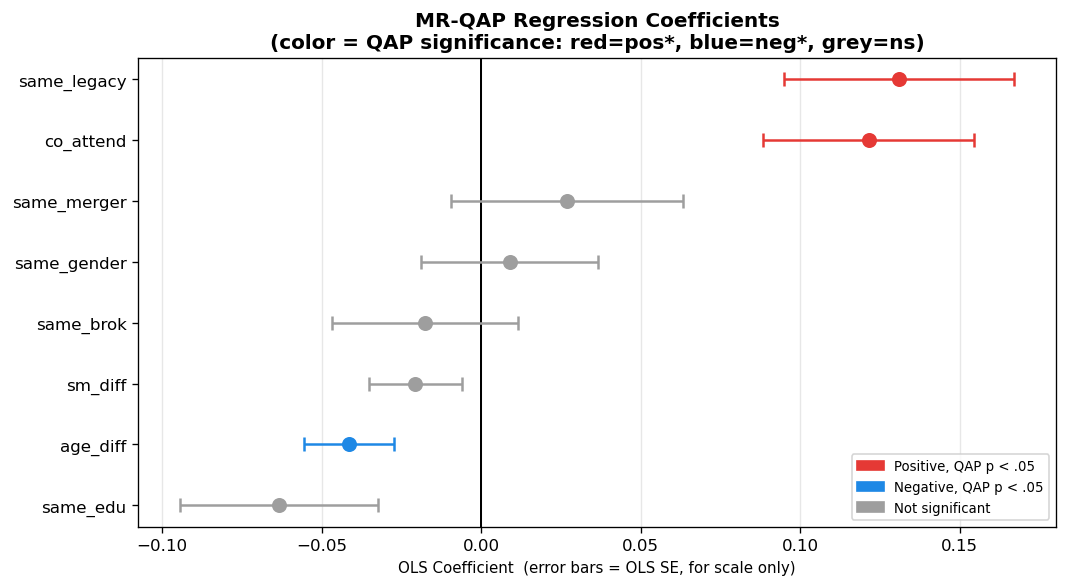

Saved: qap_coefficients.png


In [25]:
# --- Forest plot (coefficient plot) ---
bse = ols_model.bse[1:]   # OLS SE — for visual scale only, not inference

sig_mask = pvals < 0.05
colors   = ['#E53935' if (s and b > 0) else '#1E88E5' if (s and b <= 0) else '#9E9E9E'
            for s, b in zip(sig_mask, obs_coefs)]

order = np.argsort(obs_coefs)
y_pos = np.arange(len(pred_names))

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvline(0, color='black', linewidth=1.2)

for i, idx in enumerate(order):
    ax.errorbar(obs_coefs[idx], i,
                xerr=bse[idx],
                fmt='o', color=colors[idx], markersize=8,
                capsize=4, elinewidth=1.5, capthick=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([pred_names[i] for i in order], fontsize=10)
ax.set_xlabel('OLS Coefficient  (error bars = OLS SE, for scale only)', fontsize=9)
ax.set_title('MR-QAP Regression Coefficients\n(color = QAP significance: red=pos*, blue=neg*, grey=ns)',
             fontweight='bold')

legend_els = [
    mpatches.Patch(color='#E53935', label='Positive, QAP p < .05'),
    mpatches.Patch(color='#1E88E5', label='Negative, QAP p < .05'),
    mpatches.Patch(color='#9E9E9E', label='Not significant'),
]
ax.legend(handles=legend_els, fontsize=8, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('qap_coefficients.png', bbox_inches='tight')
plt.show()
print('Saved: qap_coefficients.png')

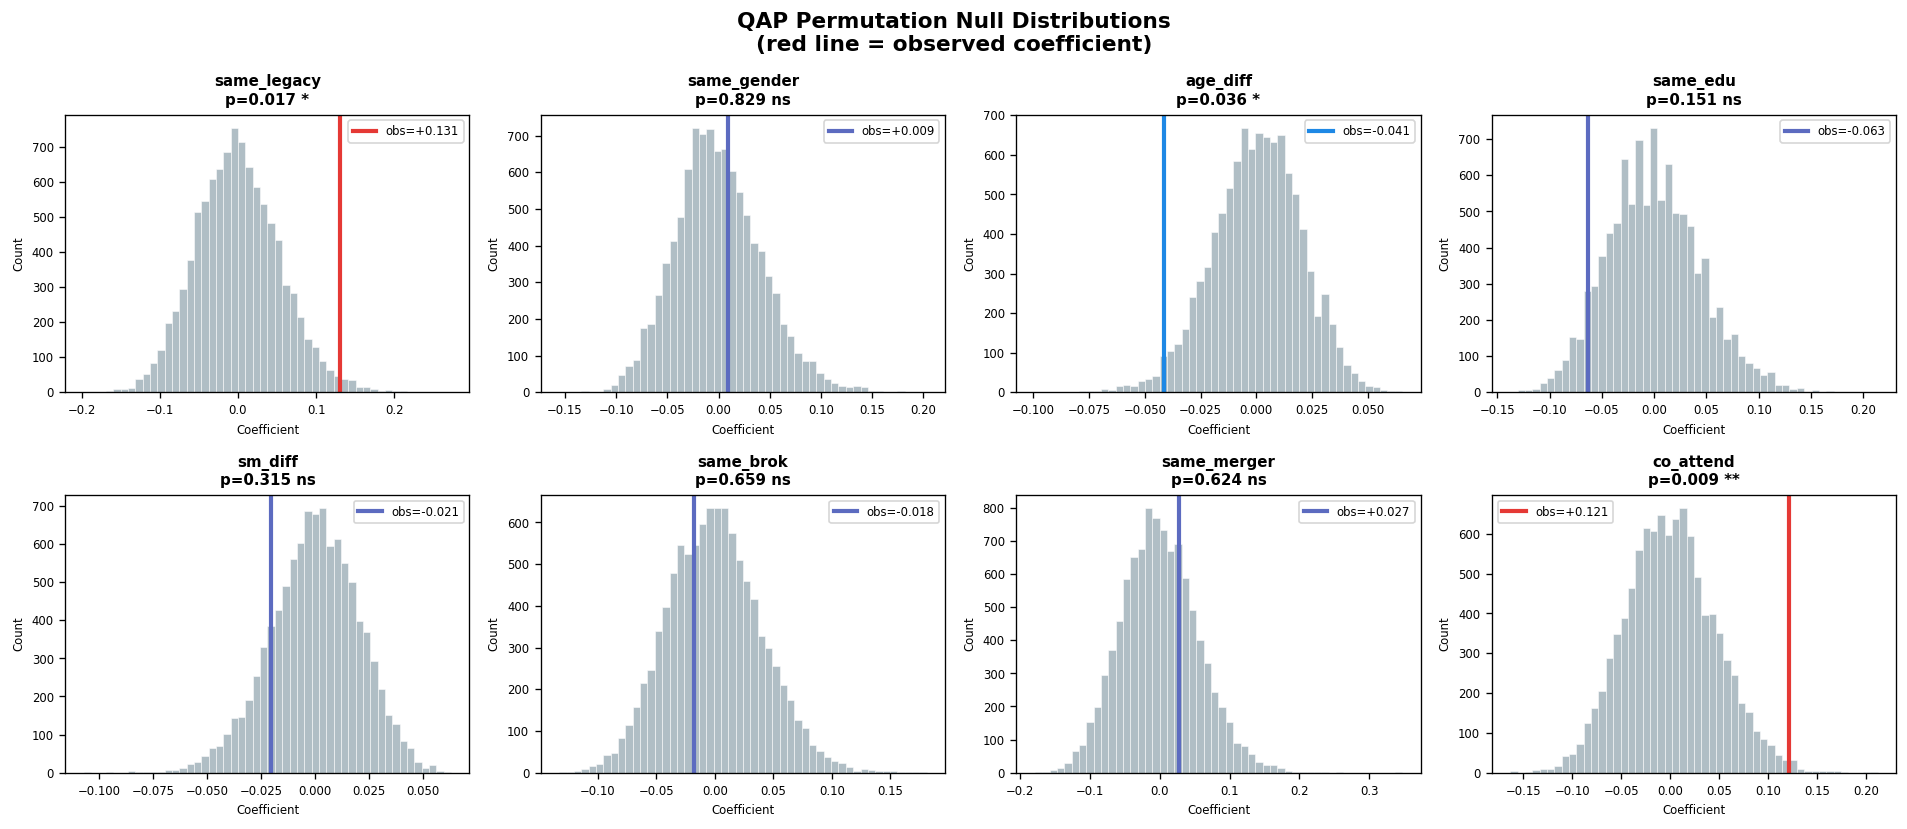

Saved: qap_permutation_dists.png


In [26]:
# --- Permutation distribution histograms (one per predictor) ---
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('QAP Permutation Null Distributions\n(red line = observed coefficient)',
             fontsize=13, fontweight='bold')

for i, (name, ax) in enumerate(zip(pred_names, axes.flat)):
    pval  = pvals[i]
    stars = sig_stars(pval)
    color = '#E53935' if (pval < 0.05 and obs_coefs[i] > 0) else \
            '#1E88E5' if (pval < 0.05 and obs_coefs[i] <= 0) else '#5C6BC0'

    ax.hist(null_coefs[:, i], bins=50, color='#B0BEC5', edgecolor='white', linewidth=0.3)
    ax.axvline(obs_coefs[i], color=color, linewidth=2.5, label=f'obs={obs_coefs[i]:+.3f}')
    ax.set_title(f'{name}\np={pval:.3f} {stars}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Coefficient', fontsize=7)
    ax.set_ylabel('Count', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('qap_permutation_dists.png', bbox_inches='tight')
plt.show()
print('Saved: qap_permutation_dists.png')

### 5.1 Interpretation

**Model fit:** R² ≈ 0.09 (QAP p ≈ .001) — demographics + co-attendance explain ~9% of tie variance. Modest but statistically robust.

---

**Significant predictors (QAP p < .05):**

| Predictor | Direction | Interpretation |
|---|---|---|
| `same_legacy` | β ≈ +0.13 | Managers **22% more likely** to communicate with same-legacy peers — legacy silos persist post-merger |
| `age_diff` | β ≈ −0.04/SD | Greater age gap → fewer ties. Generational homophily in communication |
| `co_attend` | β ≈ +0.12 | Each shared event → **+12pp tie probability**. Strongest and most actionable effect |

**Non-significant (QAP p > .05):** gender, education, self-monitoring, brokerage orientation, merger stance.

---

**Key takeaways for integration strategy:**

1. **Legacy identity is the main structural barrier** — not personality or opinions, but which company you came from.
2. **Shared events are the most effective lever** — deliberately mixing legacy groups at future events directly breaks down silos.
3. **Merger stance does not independently drive communication** — once controlling for legacy org, pro/anti-merger alignment doesn't cluster ties. Polarisation is organisational, not ideological.
4. The three task-force members (M1, M6, M17) span all three legacy groups and are cross-legacy bridges — consistent with this finding.

## 6. Suspected Saboteur Risk Analysis

The CEO suspects active sabotage of integration efforts. We model sabotage risk as a composite of **capability** (structural reach) and **motivation** (merger opposition), revised using QAP findings.

**QAP revision:** Prior models heavily weight merger stance. However, Section 5 (MR-QAP) shows stance does **not** independently predict communication ties — anti-merger managers do not selectively cluster with each other. Sabotage is therefore primarily **structural** (gatekeeping via legacy silos) rather than conspiratorial. Legacy isolation replaces part of the ideological weight.

| Risk Factor | Weight | Rationale |
|---|---|---|
| Betweenness | 35% | Structural reach to block/distort information flow |
| Anti-merger stance | 25% | Direct motivation — reduced from 35% (QAP: no ideological clustering) |
| Betweenness × Legacy isolation | 20% | Gatekeeper interaction term — see below |
| 1 − Constraint | 10% | Cross-group bridge position — reduced (interaction absorbs silo signal) |
| Self-monitoring × opposition | 5% | Selective activation of resistance |
| TG orientation | 5% | Exploits structural divisions for personal gain |

**Legacy isolation** (fraction of ties within same legacy group) distinguishes two structurally different profiles that betweenness alone cannot separate: a *cross-legacy bridge* (low isolation, high betweenness — integration asset) from a *silo gatekeeper* (high isolation, high betweenness — sits on cross-legacy shortest paths but remains deeply embedded in one camp). QAP confirms `same_legacy` is the strongest significant predictor of tie formation (β ≈ +0.13, p < .05), validating legacy embeddedness as the primary structural barrier.

Critically, legacy isolation is included as an **interaction with betweenness** (`Betweenness_n × legacy_iso_n`), not as a standalone additive term. A peripheral manager with 100% within-legacy ties cannot block cross-legacy information flow — no paths route through them. The risk only materialises when high isolation combines with high betweenness: the manager controls a structural crossing *and* is embedded in the hostile camp. A standalone term would incorrectly inflate the risk score of structurally irrelevant managers; the interaction correctly collapses to zero when betweenness is near zero regardless of how siloed the manager is.

**TG orientation** is retained as a motivation indicator despite `same_brok` being non-significant in the QAP regression. The QAP result means TG managers do not spontaneously cluster together — it says nothing about their capacity for deliberate disruptive behaviour. *Tertius Gaudens* is a conscious strategic disposition to exploit structural gaps for personal gain. In a context where employees are knowingly opposed to the merger, TG orientation signals willingness to leverage one's structural position against integration, an active choice qualitatively distinct from the passive homophily effects the QAP measures.

In [ ]:
risk = centrality_df.copy()

for col in ['Betweenness', 'Constraint', 'Self_Monitoring']:
    rng = risk[col].max() - risk[col].min()
    risk[col+'_n'] = (risk[col] - risk[col].min()) / rng if rng > 0 else 0

# Legacy isolation: fraction of ties within same legacy group
def legacy_isolation(manager_id, graph, leg_lookup):
    nbrs = list(graph.neighbors(manager_id))
    if not nbrs:
        return 0.0
    own_leg = leg_lookup.get(manager_id)
    same    = sum(1 for nb in nbrs if leg_lookup.get(nb) == own_leg)
    return same / len(nbrs)

risk['legacy_iso'] = risk['Manager'].apply(lambda m: legacy_isolation(m, G, legacy_lookup))
rng = risk['legacy_iso'].max() - risk['legacy_iso'].min()
risk['legacy_iso_n'] = (risk['legacy_iso'] - risk['legacy_iso'].min()) / rng if rng > 0 else 0

risk['against'] = (risk['Favor_Merger'] == 'N').astype(int)
risk['tg_flag'] = (risk['Brokerage_Orientation'] == 'TG').astype(int)

# QAP-revised weights:
# Betweenness           (0.35): structural reach — capability to block/distort information flow
# Anti-merger           (0.25): direct motivation
# Betweenness×iso       (0.20): interaction term — gatekeeper score: isolation is only dangerous
#                                when combined with high betweenness (peripheral embedded managers
#                                cannot block flow regardless of how siloed they are)
# 1−Constraint          (0.10): cross-group bridge position — reduced (interaction absorbs silo signal)
# SM × opposition       (0.05): selective activation of resistance
# TG flag               (0.05): conscious disposition to exploit structural divisions
risk['Risk_Score'] = (
    risk['Betweenness_n']                              * 0.35 +
    risk['against']                                    * 0.25 +
    risk['Betweenness_n'] * risk['legacy_iso_n']       * 0.20 +
    (1 - risk['Constraint_n'])                         * 0.10 +
    (risk['Self_Monitoring_n'] * risk['against'])      * 0.05 +
    risk['tg_flag']                                    * 0.05
)

print('Highest-risk managers:')
print(risk.sort_values('Risk_Score', ascending=False)[
    ['Manager','Legacy_Organization','Favor_Merger','Brokerage_Orientation',
     'Self_Monitoring','Degree','Betweenness','legacy_iso','Risk_Score']
].head(10).round(3).to_string(index=False))

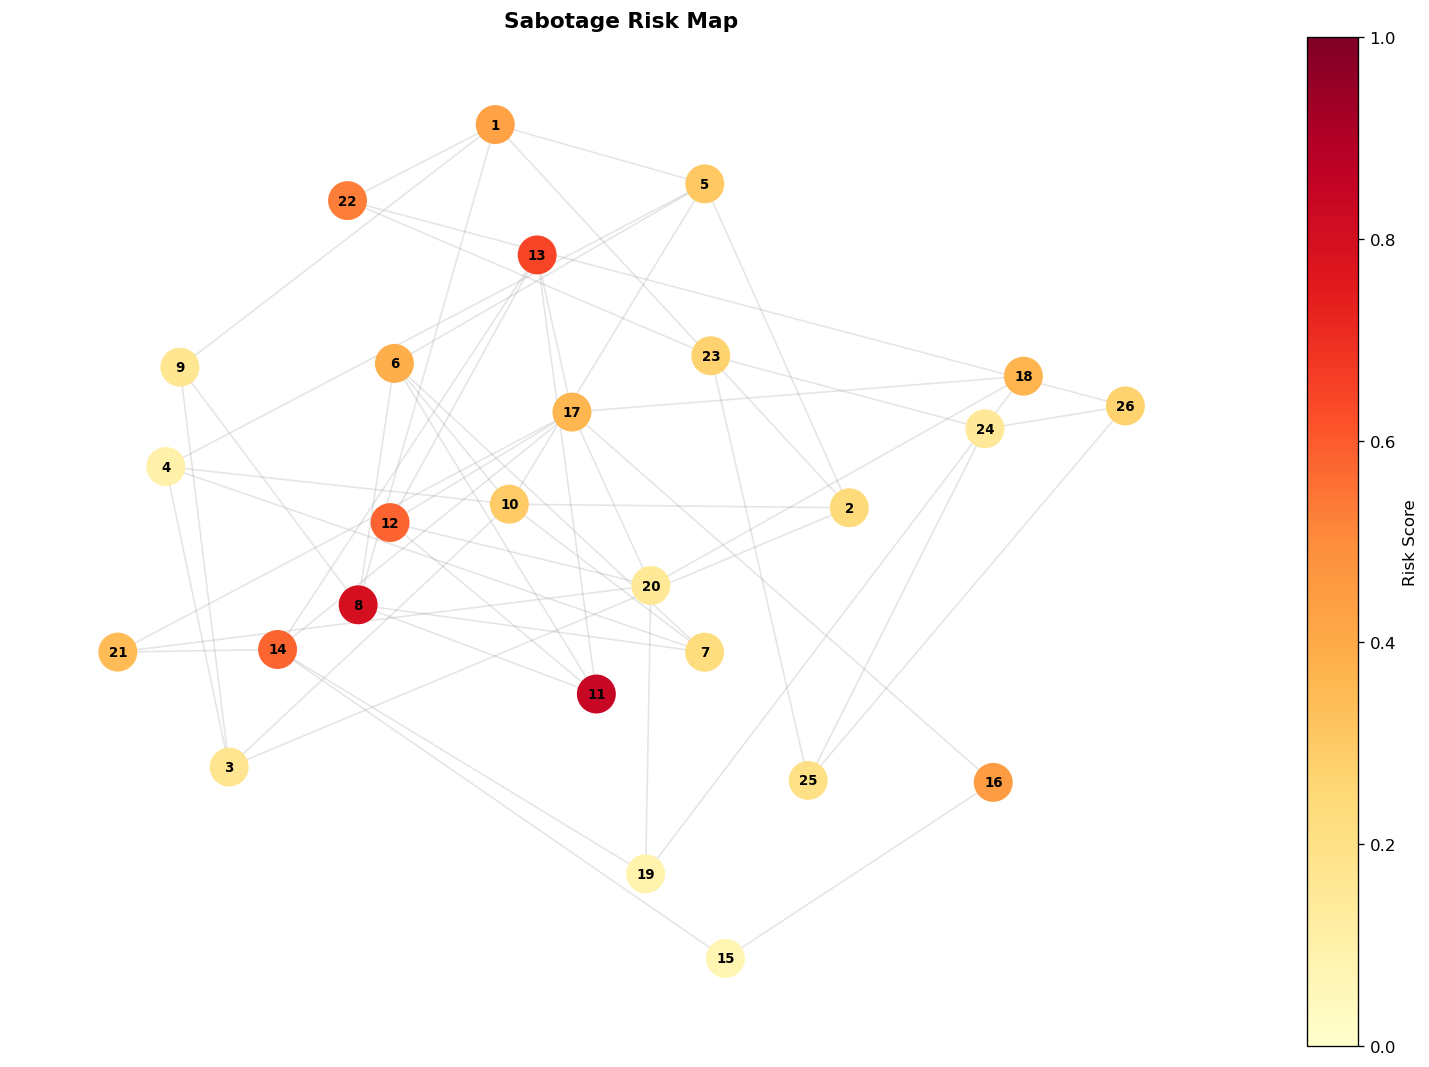

In [28]:
risk_map  = dict(zip(risk['Manager'], risk['Risk_Score']))
risk_vals = np.array([risk_map.get(n, 0) for n in G.nodes()])
cmap_r    = plt.cm.YlOrRd

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='grey', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=risk_vals, cmap=cmap_r,
                       node_size=500, ax=ax, vmin=0, vmax=1)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=plt.Normalize(0,1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Risk Score')
ax.set_title('Sabotage Risk Map', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('risk_map.png', bbox_inches='tight')
plt.show()

**Highest-risk profiles:**
- **M11** (score 0.84): Highest betweenness in the network (0.50), anti-merger, TG orientation, 50% of ties within Brightway. Classic silo gatekeeper — controls the critical Brightway–Genesisphere bridge while actively opposing integration.
- **M8** (score 0.80): Betweenness 0.35, anti-merger, TG, 80% within-Brightway ties. Second gatekeeper on the same bridge.
- **M13, M12, M14** (0.65–0.58): Genesisphere anti-merger bloc — cohesive resistant sub-cluster with moderate betweenness.

The CEO's concern about sabotage is most credible for **M11 and M8**, who sit on the only structural bridge between the two legacy clusters while actively opposing the merger. Their removal or neutralisation should be prioritised before the task force launch.

## 7. Task Force Recommendation

The task force should act as an **integration engine** — members must bridge legacy groups, move information across clusters, and actively support the merger.

**Selection criteria (QAP-informed):**
1. **Cross-legacy representation** (one per origin) — QAP confirms `same_legacy` is the strongest demographic predictor of ties (β ≈ +0.13, p < .05), making legacy diversity the non-negotiable criterion
2. **High betweenness centrality** — structural reach to influence the whole network
3. **Pro-integration orientation** — anti-merger managers excluded regardless of structural position; motivation to act matters even if stance doesn't predict organic tie formation
4. **TI brokerage tendency** — collaborative brokers who connect rather than exploit structural divisions

In [29]:
tf = centrality_df.copy()
tf = tf.merge(demo[['Manager','Age']], on='Manager')

for col in ['Betweenness','Closeness','Self_Monitoring']:
    rng = tf[col].max() - tf[col].min()
    tf[col+'_n'] = (tf[col] - tf[col].min()) / rng if rng > 0 else 0

tf['ti_flag']  = (tf['Brokerage_Orientation'] == 'TI').astype(int)
tf['fav_flag'] = (tf['Favor_Merger'] == 'Y').astype(int)
tf['leg_val']  = tf['Legacy_Organization'].apply(
    lambda x: 1.0 if x in ['Brightway','Genesisphere'] else 0.5)

# QAP-revised weights:
# Betweenness    (0.40): structural reach — most critical for cross-legacy integration
# Closeness      (0.15): fast network access
# Self_Monitoring(0.15): behavioural adaptability across groups
# leg_val        (0.15): legacy diversity — raised (QAP: legacy = primary barrier)
# ti_flag        (0.10): collaborative brokerage — reduced (QAP: not a significant tie predictor)
# fav_flag       (0.05): tiebreaker only — merger support is a prerequisite enforced by filter below
tf['TF_Score'] = (
    tf['Betweenness_n']    * 0.40 +
    tf['Closeness_n']      * 0.15 +
    tf['Self_Monitoring_n']* 0.15 +
    tf['leg_val']          * 0.15 +
    tf['ti_flag']          * 0.10 +
    tf['fav_flag']         * 0.05
)

# Pre-filter: exclude anti-merger managers (Favor_Merger == 'N')
# Task force requires motivation to integrate — opposing managers would undermine the mission
# QAP shows stance does not predict ties, but it predicts willingness to act
tf_candidates = tf[tf['Favor_Merger'] != 'N'].copy()

# Enforce one representative per legacy origin (max 1 Brightway, 1 Genesisphere, 1 Post-merger)
# QAP confirms legacy org is the primary silo driver → diversity is non-negotiable
selected, orgs_covered = [], set()
for _, row in tf_candidates.sort_values('TF_Score', ascending=False).iterrows():
    if len(selected) == 3: break
    org = row['Legacy_Organization']
    if org in orgs_covered: continue          # already have this origin represented
    if org == 'Post-merger' and len(orgs_covered) < 2: continue  # legacy orgs fill first
    selected.append(row)
    orgs_covered.add(org)

tf_final = pd.DataFrame(selected)
print('=== RECOMMENDED 3-PERSON TASK FORCE (QAP-revised) ===')
print(tf_final[['Manager','Legacy_Organization','Favor_Merger',
                'Brokerage_Orientation','Self_Monitoring',
                'Degree','Betweenness','TF_Score']].round(3).to_string(index=False))

=== RECOMMENDED 3-PERSON TASK FORCE (QAP-revised) ===
 Manager Legacy_Organization Favor_Merger Brokerage_Orientation  Self_Monitoring  Degree  Betweenness  TF_Score
       6           Brightway            Y                    TI                4       5        0.166     0.673
      17        Genesisphere            Y                    TI                4       7        0.159     0.614
      26         Post-merger          N/A                    TI                5       3        0.073     0.413


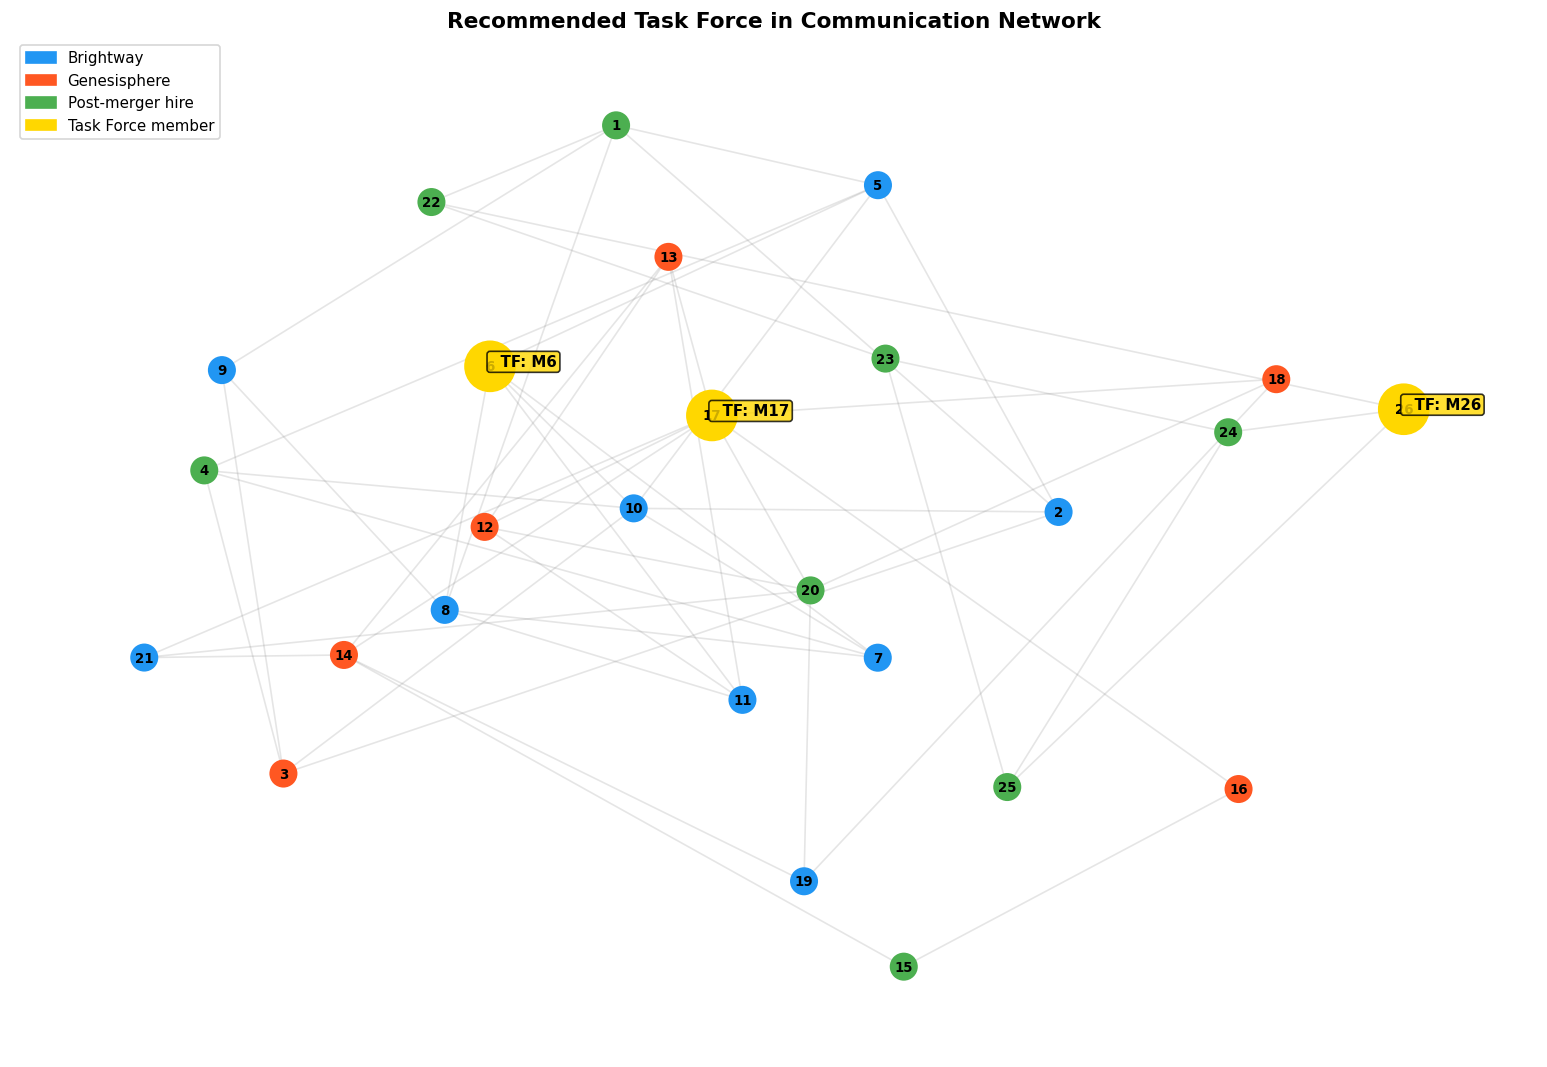

In [30]:
tf_ids = list(tf_final['Manager'].astype(int))

tf_node_colors = ['#FFD700' if n in tf_ids else node_color(n) for n in G.nodes()]
tf_node_sizes  = [900 if n in tf_ids else 250 for n in G.nodes()]

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='grey', ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=tf_node_colors, node_size=tf_node_sizes, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

for mid in tf_ids:
    x, y = pos[mid]
    ax.annotate(f'  TF: M{mid}', xy=(x,y), fontsize=9, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='#FFD700', alpha=0.8))

ax.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Brightway'),
    mpatches.Patch(color='#FF5722', label='Genesisphere'),
    mpatches.Patch(color='#4CAF50', label='Post-merger hire'),
    mpatches.Patch(color='#FFD700', label='Task Force member'),
], loc='upper left', fontsize=9)
ax.set_title('Recommended Task Force in Communication Network',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('task_force.png', bbox_inches='tight')
plt.show()

**Recommended task force:**
- **M6** (Brightway, TI, pro-merger, betweenness = 0.17): Key Brightway connector with collaborative orientation. Bridges Brightway's dense core to cross-legacy ties.
- **M17** (Genesisphere, TI, pro-merger, betweenness = 0.16): Genesisphere's best-positioned pro-merger broker. Highest degree in the network (7 connections) — counterweight to the Genesisphere anti-merger bloc.
- **M26** (Post-merger, TI, N/A, betweenness = 0.07): Represents the post-merger hires — the structurally most isolated cluster. Bridges C3 to the rest of the network.

Together, M6 + M17 + M26 span all three legacy origins and all three structural communities detected in Section 4.3. All hold TI brokerage orientations, maximising both structural reach and collaborative intent.

## 8. Full Summary

In [31]:
print('=== NETWORK STATISTICS ===')
Gcc = G.subgraph(max(nx.connected_components(G), key=len))
print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges (undirected): {G.number_of_edges()}')
print(f'Density: {nx.density(G):.4f}')
print(f'Avg degree: {np.mean(list(dict(G.degree()).values())):.2f}')
print(f'Avg clustering coefficient: {nx.average_clustering(G):.4f}')
print(f'Avg shortest path (main component): {nx.average_shortest_path_length(Gcc):.4f}')
print(f'Diameter: {nx.diameter(Gcc)}')
print(f'Communities (greedy modularity): {len(communities)}')
print(f'Modularity Q: {modularity:.4f}')

=== NETWORK STATISTICS ===
Nodes: 26
Edges (undirected): 51
Density: 0.1569
Avg degree: 3.92
Avg clustering coefficient: 0.3777
Avg shortest path (main component): 3.5938
Diameter: 8
Communities (greedy modularity): 3
Modularity Q: 0.5554


In [32]:
print('=== FULL MANAGER TABLE ===')
print(centrality_df[['Manager','Legacy_Organization','Favor_Merger',
                      'Brokerage_Orientation','Self_Monitoring',
                      'Degree','Betweenness','Closeness',
                      'Constraint','events_attended']]
      .sort_values('Manager').round(4).to_string(index=False))

=== FULL MANAGER TABLE ===
 Manager Legacy_Organization Favor_Merger Brokerage_Orientation  Self_Monitoring  Degree  Betweenness  Closeness  Constraint  events_attended
       1         Post-merger          N/A                    TI                5       5       0.3556     0.3571      0.2888                3
       2           Brightway            Y                    TG                2       4       0.0211     0.2907      0.4232                1
       3        Genesisphere            Y                    TG                1       4       0.0094     0.2747      0.3733                2
       4         Post-merger          N/A                    TI                3       4       0.0039     0.2747      0.4358                1
       5           Brightway            Y                    TG                4       5       0.0653     0.3378      0.3617                2
       6           Brightway            Y                    TI                4       5       0.1664     0.3623      0.3